In [ ]:
import os, re, random, html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

SEED = 42
random.seed(SEED); np.random.seed(SEED)

TEXT_COL = "review"
LABEL_COL = "sentiment"
df=pd.read_csv("/content/IMDB Dataset.csv")



Class counts:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Length stats:
 count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: len, dtype: float64


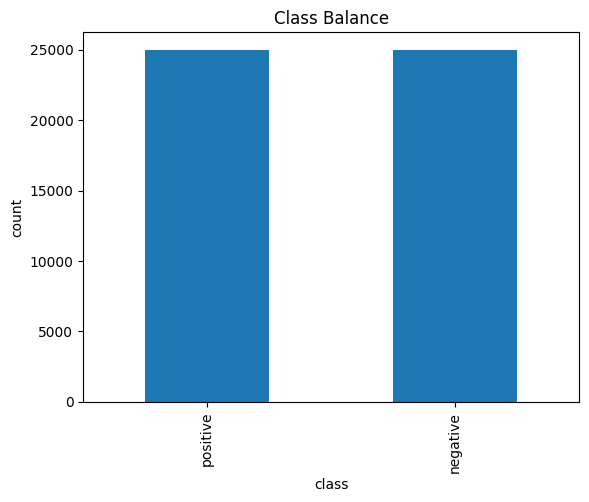

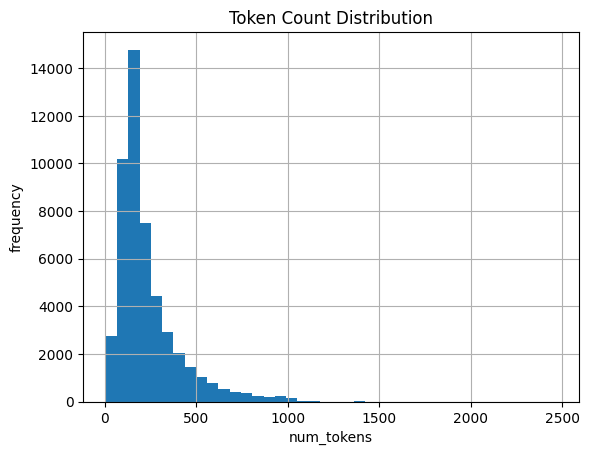

In [ ]:
# Normalize label casing
df[LABEL_COL] = df[LABEL_COL].str.lower().str.strip()

# Keep only positive/negative
valid = df[LABEL_COL].isin(["positive", "negative"])
df = df[valid].copy().reset_index(drop=True)

# Show class counts
cls_counts = df[LABEL_COL].value_counts()
print("Class counts:\n", cls_counts)

# Text length
df["len"] = df[TEXT_COL].astype(str).apply(lambda s: len(s.split()))
print("Length stats:\n", df["len"].describe())

# (Optional) Visuals
plt.figure()
cls_counts.plot(kind="bar")
plt.title("Class Balance")
plt.xlabel("class"); plt.ylabel("count")
plt.show()

plt.figure()
df["len"].hist(bins=40)
plt.title("Token Count Distribution")
plt.xlabel("num_tokens"); plt.ylabel("frequency")
plt.show()


In [ ]:
# Preprocessing
URL_RE = re.compile(r"http[s]?://\\S+|www\\.\\S+")
TAG_RE = re.compile(r"<.*?>")
MULTISPACE_RE = re.compile(r"\\s+")

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = html.unescape(s)
    s = TAG_RE.sub(" ", s)                   # remove HTML tags
    s = URL_RE.sub(" ", s)                   # remove URLs
    s = s.replace("\n", " ").replace("\r", " ")
    s = re.sub(r"[^A-Za-z0-9'\\s.,!?]", " ", s)  # keep simple ascii + basic punct
    s = MULTISPACE_RE.sub(" ", s)
    return s.strip()

df["text_clean"] = df[TEXT_COL].apply(clean_text)

# Map labels to ints for classical model if needed (optional)
label2id = {"negative":0, "positive":1}
id2label = {v:k for k,v in label2id.items()}
y_int = df[LABEL_COL].map(label2id).astype(int)

print("Sample cleaned:\n", df[["review","text_clean",LABEL_COL]].head(3))


Sample cleaned:
                                               review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   

                                          text_clean sentiment  
0  One of the other reviewers has mentioned that ...  positive  
1  A wonderful little production.   The filming t...  positive  
2  I thought this was a wonderful way to spend ti...  positive  


In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"].values,
    y_int.values,
    test_size=0.2,
    random_state=SEED,
    stratify=y_int
)

print("Train size:", len(X_train), "Test size:", len(X_test))


Train size: 40000 Test size: 10000


In [ ]:
# TF-IDF + Logistic

tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        random_state=SEED,
        max_iter=200,
        n_jobs=None,
        class_weight=None
    ))
])

tfidf_logreg.fit(X_train, y_train)
pred = tfidf_logreg.predict(X_test)
acc = accuracy_score(y_test, pred)
p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)

print(f"Baseline (TF-IDF+LogReg) — Acc: {acc:.4f} | F1: {f1:.4f} | P: {p:.4f} | R: {r:.4f}")
print("\nClassification Report:\n", classification_report(y_test, pred, target_names=["negative","positive"]))


Baseline (TF-IDF+LogReg) — Acc: 0.9068 | F1: 0.9076 | P: 0.9002 | R: 0.9150

Classification Report:
               precision    recall  f1-score   support

    negative       0.91      0.90      0.91      5000
    positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:
# Transformer (BERT) — Optional
!pip -q install transformers datasets accelerate

import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

MODEL_NAME = "bert-base-uncased"
NUM_LABELS = 2

# Prepare HF Datasets
train_ds = Dataset.from_dict({"text": X_train, "label": y_train})
test_ds  = Dataset.from_dict({"text": X_test,  "label": y_test})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

train_enc = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_enc  = test_ds.map(tokenize_fn, batched=True, remove_columns=["text"])

train_enc.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_enc.set_format(type="torch", columns=["input_ids","attention_mask","label"])

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {"accuracy": acc, "f1": f1, "precision": p, "recall": r}

# Training args
training_args = TrainingArguments(
    output_dir="/tmp/ignore_outputs",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_strategy="steps",
    save_strategy="no",
    report_to="none",
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_enc,
    eval_dataset=test_enc,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()
eval_res = trainer.evaluate()
print("BERT Eval:", eval_res)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1123027287.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.317600
1000,0.256100
1500,0.233300
2000,0.215900
2500,0.208100
3000,0.134300
3500,0.137500
4000,0.135400
4500,0.131900
5000,0.122600


BERT Eval: {'eval_loss': 0.24412143230438232, 'eval_accuracy': 0.9325, 'eval_f1': 0.9327354260089686, 'eval_precision': 0.929493545183714, 'eval_recall': 0.936, 'eval_runtime': 145.7998, 'eval_samples_per_second': 68.587, 'eval_steps_per_second': 2.147, 'epoch': 2.0}


In [ ]:
# Compare
baseline_pred = pred
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1  = f1_score(y_test, baseline_pred)

print(f"Baseline  -> Acc: {baseline_acc:.4f} | F1: {baseline_f1:.4f}")
try:
    print(f"BERT      -> Acc: {eval_res.get('eval_accuracy', None)} | F1: {eval_res.get('eval_f1', None)}")
except:
    print("BERT not run yet.")


Baseline  -> Acc: 0.9068 | F1: 0.9076
BERT      -> Acc: 0.9325 | F1: 0.9327354260089686


In [ ]:
############################################################